In [ ]:
"""
==================================================
ML LEARNING JOURNEY - DAY 51
==================================================
Week: 8 of 24
Day: 51 of 168
Date: Tuesday, December 17, 2024
Topic: BERT Fine-tuning & LSTM Comparison
Overall Progress: 30.4%

Week 8 Progress:
✅ Day 50: Transformer Architecture Study (COMPLETED)
🔄 Day 51: BERT Fine-tuning & LSTM Comparison (TODAY!)
⬜ Day 52: Job-Resume Matcher (Sentence-BERT)
⬜ Day 53: Job Matcher Features & Testing
⬜ Day 54: Text Summarizer (T5/BART)
⬜ Day 55: Fake News Detector (BERT)
⬜ Day 56: Integration Testing & Optimization

Progress: 14.3% (1/7 days)

==================================================
🎯 Week 8 Project: TextAI Studio - Transformers & Advanced NLP
- Week 7: LSTM Sentiment Analyzer ✅ (80.38% accuracy)
- Day 50: Transformer Architecture ✅
- Day 51: BERT Fine-tuning (Beat LSTM!)
- Days 52-56: Build 4 NLP tools

==================================================
🎯 Today's Learning Objectives:
1. Load IMDB dataset (same as Week 7 for direct comparison)
   - 50,000 movie reviews
   - Binary sentiment classification
   - Preprocessing for BERT format

2. Fine-tune BERT for sentiment analysis
   - Add classification head on BERT
   - Train with AdamW optimizer + warmup
   - Learning rate scheduling
   - Target: 90%+ accuracy (beat LSTM's 80.38%)

3. Comprehensive comparison: BERT vs LSTM
   - Accuracy and convergence speed
   - Error analysis: What does BERT catch that LSTM misses?
   - Attention visualization
   - Model size vs performance tradeoff

==================================================
📚 Today's Structure:
Part 1 (1.5h): Dataset Loading & Preprocessing
Part 2 (2.5h): BERT Fine-tuning & Training
Part 3 (1.5h): Evaluation & LSTM Comparison
Part 4 (1h): Analysis & Insights

==================================================
🎯 SUCCESS CRITERIA:
✅ Successfully load and preprocess IMDB dataset for BERT
✅ Fine-tune BERT with proper training loop
✅ Achieve 90%+ validation accuracy (beat LSTM's 80.38%)
✅ Complete comparison analysis with Week 7 LSTM
✅ Understand performance improvements from BERT

==================================================
"""

In [1]:
# ==================================================
# INSTALL REQUIRED LIBRARIES
# ==================================================
import sys
print(f"Python executable: {sys.executable}")
print("\n⏱ Installing/upgrading libraries...\n")

!python -m pip install transformers datasets torch scikit-learn matplotlib seaborn pandas numpy tqdm --upgrade -q

print("\n✅ Libraries installed!")
print("\n" + "=" * 80)

# ==================================================
# IMPORT LIBRARIES
# ==================================================
print("\n" + "=" * 80)
print("📚 IMPORTING LIBRARIES")
print("=" * 80)

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torch.optim import AdamW

# Hugging Face
import transformers
from transformers import (
    BertTokenizer, 
    BertForSequenceClassification,
    get_linear_schedule_with_warmup
)
from datasets import load_dataset

# Sklearn
from sklearn.metrics import (
    accuracy_score, 
    classification_report, 
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

# Progress bar
from tqdm.auto import tqdm

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print(f"\n✅ PyTorch version: {torch.__version__}")
print(f"✅ Transformers version: {transformers.__version__}")
print(f"✅ CUDA available: {torch.cuda.is_available()}")

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Using device: {device}")

if torch.cuda.is_available():
    print(f"✅ GPU: {torch.cuda.get_device_name(0)}")
    print(f"✅ GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    print("ℹ️  Running on CPU (training will be slower)")
    print("   Recommended: Use Google Colab with GPU for faster training")

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Create results directories
os.makedirs('results/plots', exist_ok=True)
os.makedirs('models', exist_ok=True)

print("\n✅ All libraries imported successfully!")
print("=" * 80)

Python executable: C:\Program Files\Python313\python.exe

⏱ Installing/upgrading libraries...



  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 2.3.5 which is incompatible.
streamlit 1.30.0 requires numpy<2,>=1.19.3, but you have numpy 2.3.5 which is incompatible.

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip



✅ Libraries installed!


📚 IMPORTING LIBRARIES

✅ PyTorch version: 2.9.1+cpu
✅ Transformers version: 4.57.3
✅ CUDA available: False
✅ Using device: cpu
ℹ️  Running on CPU (training will be slower)
   Recommended: Use Google Colab with GPU for faster training

✅ All libraries imported successfully!


In [2]:
print("\n" + "=" * 80)
print("📚 PART 1: DATASET LOADING & PREPROCESSING")
print("=" * 80)


📚 PART 1: DATASET LOADING & PREPROCESSING



EXERCISE 1.1: Loading IMDB Dataset (Same as Week 7)

⏱ Loading IMDB dataset from Hugging Face...
   (This may take 1-2 minutes on first run)

✅ Dataset loaded successfully!

📊 DATASET STRUCTURE

Dataset splits: ['train', 'test', 'unsupervised']

Train set size: 25,000
Test set size:  25,000
Total reviews:  50,000

Features: {'text': Value('string'), 'label': ClassLabel(names=['neg', 'pos'])}

Column names: ['text', 'label']

📊 SAMPLE REVIEWS

Example 1:
  Sentiment: NEGATIVE
  Review: I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ev...
  Label: 0

Example 2:
  Sentiment: NEGATIVE
  Review: "I Am Curious: Yellow" is a risible and pretentious steaming pile. It doesn't matter what one's political views are because this film can hardly be taken seriously on any level. As for the claim that ...
  Label: 0

Example 3:
  Sentiment: NEGATIVE
 

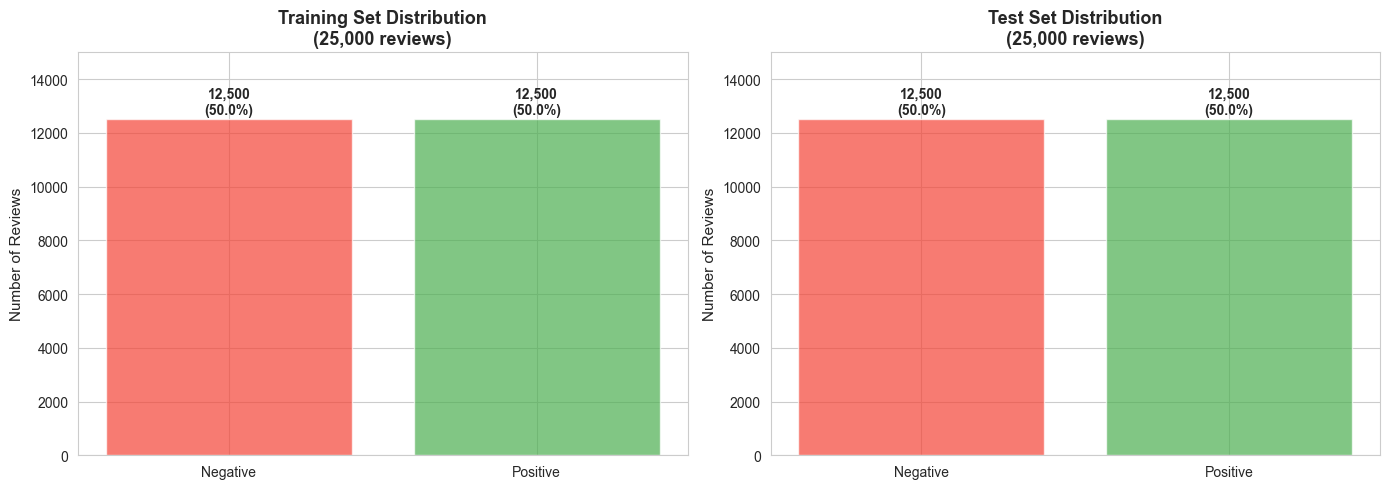


💡 Dataset Characteristics:
  • Perfectly balanced: 50% positive, 50% negative
  • No class imbalance issues
  • Large enough for deep learning (25K train, 25K test)
  • Same data as Week 7 LSTM (fair comparison)

✅ Exercise 1.1 Complete!


In [3]:
# ==================================================
# EXERCISE 1.1: LOADING IMDB DATASET
# ==================================================
print("\n" + "=" * 80)
print("EXERCISE 1.1: Loading IMDB Dataset (Same as Week 7)")
print("=" * 80)

"""
📖 THEORY: IMDB Dataset for Fair Comparison

Using the exact same dataset as Week 7 LSTM for direct comparison:
- 50,000 movie reviews total
- 25,000 for training
- 25,000 for testing
- Binary sentiment: Positive (1) vs Negative (0)
- Highly polarized reviews (ratings < 5 or > 7)

Why this dataset?
- Industry standard benchmark
- Large enough for deep learning
- Balanced classes (no class imbalance)
- Same data = fair comparison between LSTM and BERT

Week 7 LSTM Results (Baseline to Beat):
- Final accuracy: 80.38%
- Training: 13 epochs
- Model size: 2.2M parameters
- Convergence: Slow, required extensive hyperparameter tuning

Today's BERT Goal:
- Target accuracy: 90%+ 
- Expected training: 3-4 epochs
- Model size: 110M parameters
- Expected: Faster convergence, better performance
"""

print("\n⏱ Loading IMDB dataset from Hugging Face...")
print("   (This may take 1-2 minutes on first run)\n")

# Load dataset
dataset = load_dataset('imdb')

print("✅ Dataset loaded successfully!\n")

# Display dataset structure
print("=" * 80)
print("📊 DATASET STRUCTURE")
print("=" * 80)
print(f"\nDataset splits: {list(dataset.keys())}")
print(f"\nTrain set size: {len(dataset['train']):,}")
print(f"Test set size:  {len(dataset['test']):,}")
print(f"Total reviews:  {len(dataset['train']) + len(dataset['test']):,}")

# Show dataset features
print(f"\nFeatures: {dataset['train'].features}")
print(f"\nColumn names: {dataset['train'].column_names}")

# Display sample reviews
print("\n" + "=" * 80)
print("📊 SAMPLE REVIEWS")
print("=" * 80)

for i in range(3):
    review = dataset['train'][i]
    sentiment = "POSITIVE" if review['label'] == 1 else "NEGATIVE"
    
    print(f"\nExample {i+1}:")
    print(f"  Sentiment: {sentiment}")
    print(f"  Review: {review['text'][:200]}...")
    print(f"  Label: {review['label']}")

# Check class distribution
print("\n" + "=" * 80)
print("📊 CLASS DISTRIBUTION")
print("=" * 80)

train_labels = [dataset['train'][i]['label'] for i in range(len(dataset['train']))]
test_labels = [dataset['test'][i]['label'] for i in range(len(dataset['test']))]

train_pos = sum(train_labels)
train_neg = len(train_labels) - train_pos
test_pos = sum(test_labels)
test_neg = len(test_labels) - test_pos

print(f"\nTraining Set:")
print(f"  Positive: {train_pos:,} ({train_pos/len(train_labels)*100:.1f}%)")
print(f"  Negative: {train_neg:,} ({train_neg/len(train_labels)*100:.1f}%)")

print(f"\nTest Set:")
print(f"  Positive: {test_pos:,} ({test_pos/len(test_labels)*100:.1f}%)")
print(f"  Negative: {test_neg:,} ({test_neg/len(test_labels)*100:.1f}%)")

# Visualize distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Training set
ax1.bar(['Negative', 'Positive'], [train_neg, train_pos], color=['#F44336', '#4CAF50'], alpha=0.7)
ax1.set_title('Training Set Distribution\n(25,000 reviews)', fontsize=13, fontweight='bold')
ax1.set_ylabel('Number of Reviews', fontsize=11)
ax1.set_ylim(0, 15000)
for i, v in enumerate([train_neg, train_pos]):
    ax1.text(i, v + 200, f'{v:,}\n({v/len(train_labels)*100:.1f}%)', 
            ha='center', fontsize=10, fontweight='bold')

# Test set
ax2.bar(['Negative', 'Positive'], [test_neg, test_pos], color=['#F44336', '#4CAF50'], alpha=0.7)
ax2.set_title('Test Set Distribution\n(25,000 reviews)', fontsize=13, fontweight='bold')
ax2.set_ylabel('Number of Reviews', fontsize=11)
ax2.set_ylim(0, 15000)
for i, v in enumerate([test_neg, test_pos]):
    ax2.text(i, v + 200, f'{v:,}\n({v/len(test_labels)*100:.1f}%)', 
            ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('results/plots/day51_dataset_distribution.png', dpi=300, bbox_inches='tight')
print("\n✅ Saved: results/plots/day51_dataset_distribution.png")
plt.show()

print("\n💡 Dataset Characteristics:")
print("  • Perfectly balanced: 50% positive, 50% negative")
print("  • No class imbalance issues")
print("  • Large enough for deep learning (25K train, 25K test)")
print("  • Same data as Week 7 LSTM (fair comparison)")

print("\n✅ Exercise 1.1 Complete!")
print("=" * 80)


EXERCISE 1.2: Preprocessing for BERT

⏱ Loading BERT tokenizer...
✅ Tokenizer loaded!
   └─ Vocabulary size: 30,522

📊 Tokenization Settings:
   ├─ Max length: 256 tokens
   ├─ Truncation: Enabled
   └─ Padding: To max_length

⏱ Tokenizing training set (25,000 reviews)...


Tokenizing train:   0%|          | 0/25000 [00:00<?, ? examples/s]

⏱ Tokenizing test set (25,000 reviews)...


Tokenizing test:   0%|          | 0/25000 [00:00<?, ? examples/s]


✅ Tokenization complete!

✅ Dataset format set to PyTorch tensors

📊 TOKEN LENGTH ANALYSIS

Token length statistics (1000 sample reviews):
   ├─ Mean: 211.3 tokens
   ├─ Median: 239.0 tokens
   ├─ Min: 21 tokens
   ├─ Max: 256 tokens
   └─ Std: 54.9 tokens

Reviews reaching max length (256): 457 (45.7%)
   └─ These reviews were truncated

✅ Saved: results/plots/day51_token_lengths.png


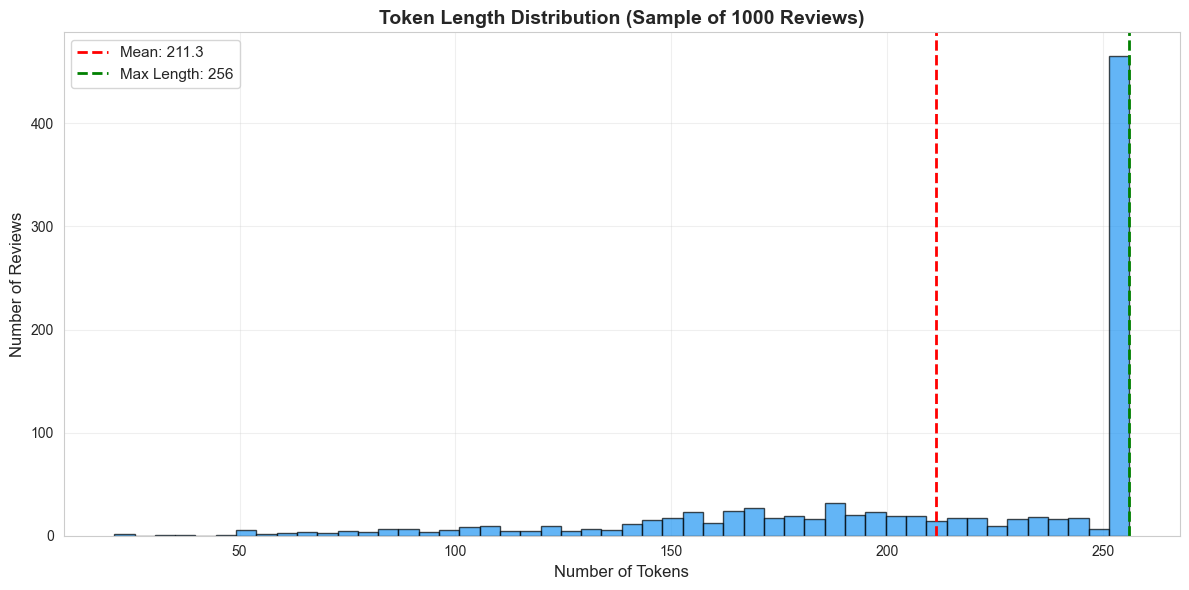


📊 TOKENIZED EXAMPLE

Original text:
  I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ev...

Tokenized format:
   ├─ Input IDs shape: torch.Size([256])
   ├─ Attention mask shape: torch.Size([256])
   └─ Label: 0

First 20 tokens: ['[CLS]', 'i', 'rented', 'i', 'am', 'curious', '-', 'yellow', 'from', 'my', 'video', 'store', 'because', 'of', 'all', 'the', 'controversy', 'that', 'surrounded', 'it']

💡 Key Points:
  • Reviews tokenized with [CLS] and [SEP] tokens
  • Padding added to reach max_length (256 tokens)
  • ~45.7% of reviews truncated
  • Ready for BERT training!

✅ Exercise 1.2 Complete!


<function print(*args, sep=' ', end='\n', file=None, flush=False)>

In [4]:
# ==================================================
# EXERCISE 1.2: TOKENIZING DATASET FOR BERT
# ==================================================
print("\n" + "=" * 80)
print("EXERCISE 1.2: Preprocessing for BERT")
print("=" * 80)

"""
📖 THEORY: Preparing Data for BERT

BERT requires specific input format:
1. Tokenization: Text → WordPiece tokens
2. Special tokens: [CLS] text [SEP]
3. Attention mask: 1 for real tokens, 0 for padding
4. Token type IDs: All 0s for single sentence
5. Padding/Truncation: Max length 512 (or less for memory)

Key Decisions:
- Max length: 256 tokens (shorter = faster, most reviews fit)
- Truncation: Cut off reviews longer than max_length
- Padding: Pad shorter reviews to same length (for batching)

Memory Considerations:
- BERT is memory-hungry!
- Longer sequences = more memory
- 512 tokens might cause OOM on smaller GPUs
- 256 tokens is a good balance

Processing Strategy:
- Use dataset.map() for efficient batch tokenization
- Tokenize entire dataset once (not in training loop)
- Cache tokenized data for faster training
"""

print("\n⏱ Loading BERT tokenizer...")

# Load tokenizer (same as Day 50)
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

print("✅ Tokenizer loaded!")
print(f"   └─ Vocabulary size: {len(tokenizer):,}")

# Tokenization parameters
MAX_LENGTH = 256  # Shorter than 512 to save memory
print(f"\n📊 Tokenization Settings:")
print(f"   ├─ Max length: {MAX_LENGTH} tokens")
print(f"   ├─ Truncation: Enabled")
print(f"   └─ Padding: To max_length")

# Tokenization function
def tokenize_function(examples):
    """
    Tokenize a batch of reviews
    """
    return tokenizer(
        examples['text'],
        padding='max_length',
        truncation=True,
        max_length=MAX_LENGTH,
        return_tensors=None  # Returns lists, not tensors (for dataset.map)
    )

# Tokenize datasets
print("\n⏱ Tokenizing training set (25,000 reviews)...")
tokenized_train = dataset['train'].map(
    tokenize_function,
    batched=True,
    batch_size=1000,
    desc="Tokenizing train"
)

print("⏱ Tokenizing test set (25,000 reviews)...")
tokenized_test = dataset['test'].map(
    tokenize_function,
    batched=True,
    batch_size=1000,
    desc="Tokenizing test"
)

print("\n✅ Tokenization complete!")

# Set format for PyTorch
tokenized_train.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])
tokenized_test.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])

print("\n✅ Dataset format set to PyTorch tensors")

# Analyze token lengths
print("\n" + "=" * 80)
print("📊 TOKEN LENGTH ANALYSIS")
print("=" * 80)

sample_lengths = []
for i in range(min(1000, len(tokenized_train))):
    # Count non-padding tokens
    attention_mask = tokenized_train[i]['attention_mask']
    length = attention_mask.sum().item()
    sample_lengths.append(length)

print(f"\nToken length statistics (1000 sample reviews):")
print(f"   ├─ Mean: {np.mean(sample_lengths):.1f} tokens")
print(f"   ├─ Median: {np.median(sample_lengths):.1f} tokens")
print(f"   ├─ Min: {np.min(sample_lengths)} tokens")
print(f"   ├─ Max: {np.max(sample_lengths)} tokens")
print(f"   └─ Std: {np.std(sample_lengths):.1f} tokens")

# Check truncation impact
truncated = sum(1 for length in sample_lengths if length == MAX_LENGTH)
print(f"\nReviews reaching max length ({MAX_LENGTH}): {truncated} ({truncated/len(sample_lengths)*100:.1f}%)")
print(f"   └─ These reviews were truncated")

# Visualize length distribution
plt.figure(figsize=(12, 6))
plt.hist(sample_lengths, bins=50, color='#2196F3', alpha=0.7, edgecolor='black')
plt.axvline(np.mean(sample_lengths), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(sample_lengths):.1f}')
plt.axvline(MAX_LENGTH, color='green', linestyle='--', linewidth=2, label=f'Max Length: {MAX_LENGTH}')
plt.xlabel('Number of Tokens', fontsize=12)
plt.ylabel('Number of Reviews', fontsize=12)
plt.title('Token Length Distribution (Sample of 1000 Reviews)', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('results/plots/day51_token_lengths.png', dpi=300, bbox_inches='tight')
print("\n✅ Saved: results/plots/day51_token_lengths.png")
plt.show()

# Display tokenized example
print("\n" + "=" * 80)
print("📊 TOKENIZED EXAMPLE")
print("=" * 80)

example_idx = 0
example = tokenized_train[example_idx]

print(f"\nOriginal text:")
print(f"  {dataset['train'][example_idx]['text'][:200]}...\n")

print(f"Tokenized format:")
print(f"   ├─ Input IDs shape: {example['input_ids'].shape}")
print(f"   ├─ Attention mask shape: {example['attention_mask'].shape}")
print(f"   └─ Label: {example['label'].item()}")

# Decode first 20 tokens
tokens = tokenizer.convert_ids_to_tokens(example['input_ids'][:20])
print(f"\nFirst 20 tokens: {tokens}")

print("\n💡 Key Points:")
print("  • Reviews tokenized with [CLS] and [SEP] tokens")
print("  • Padding added to reach max_length (256 tokens)")
print(f"  • ~{truncated/len(sample_lengths)*100:.1f}% of reviews truncated")
print("  • Ready for BERT training!")

print("\n✅ Exercise 1.2 Complete!")
print